In [ ]:
import mlflow, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, #calibration_curve,
                             brier_score_loss, f1_score)
from sklearn.calibration import calibration_curve
import snowflake.connector

SNOWFLAKE_CONFIG = {
    'user':     "",
    "password": "",
    "account": "",
    "warehouse": "TAXI_WH",
    "database": "TAXI_DB",
    "schema": "RAW"
}


mlflow.set_tracking_uri('file:./mlruns')
model = mlflow.sklearn.load_model('models:/chicago_tip_classifier/1')


conn = snowflake.connector.connect(**SNOWFLAKE_CONFIG)
df   = pd.read_sql('SELECT * FROM TAXI_DB.MARTS.MART_TRIP_FEATURES', conn)
df.columns = df.columns.str.lower()
conn.close()


FEATURES = ['pickup_hour','pickup_dow','pickup_month','is_weekend','is_late_night',
            'trip_miles','trip_minutes','fare_per_mile','fare_per_minute',
            'extras','fare','pickup_is_airport','dropoff_is_airport']
X = df[FEATURES].fillna(df[FEATURES].median())
y = df['tipped']
_, X_test, _, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


y_prob = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)


c:\Users\brand\portfolio\Tip-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\brand\portfolio\Tip-Classification\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
c:\Users\brand\portfolio\Tip-Classification\.venv\Lib\site-packages\mlflow\tracking\_model_registry\utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a 

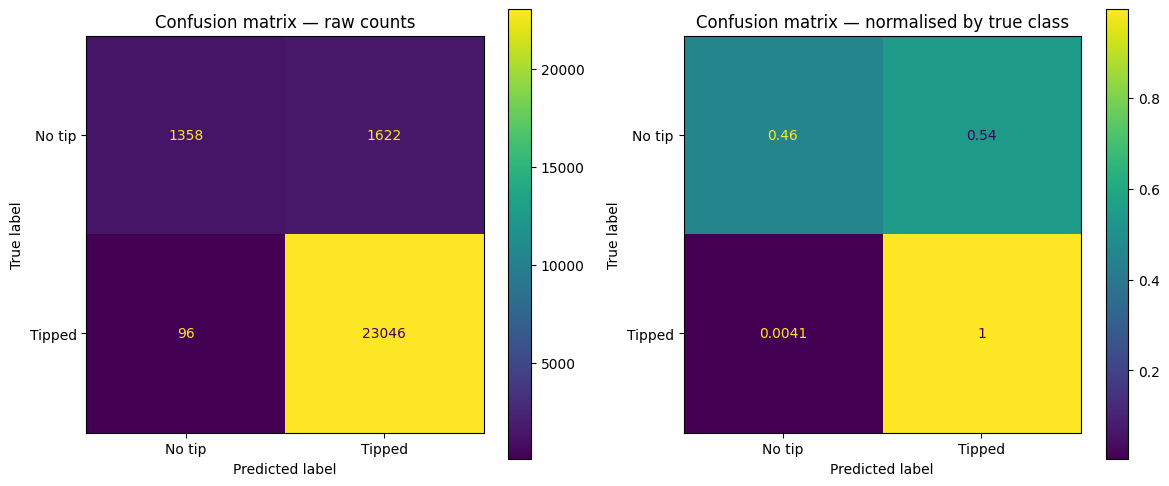

True negatives  (correct no-tip calls):      1,358
False positives (predicted tip, was no):     1,622
False negatives (missed tippers):               96
True positives  (correct tip calls):        23,046

False positive rate: 54.43% — model over-predicts tips at this rate
False negative rate: 0.41% — model misses tips at this rate


In [3]:
fig, axes = plt.subplots(1,2,figsize=(12,5))


cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No tip','Tipped']).plot(ax=axes[0])
axes[0].set_title('Confusion matrix — raw counts')


cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['No tip','Tipped']).plot(ax=axes[1])
axes[1].set_title('Confusion matrix — normalised by true class')


plt.tight_layout(); plt.savefig('confusion_matrix.png',dpi=120); plt.show()


tn, fp, fn, tp = cm.ravel()
print(f'True negatives  (correct no-tip calls):   {tn:>8,}')
print(f'False positives (predicted tip, was no):  {fp:>8,}')
print(f'False negatives (missed tippers):         {fn:>8,}')
print(f'True positives  (correct tip calls):      {tp:>8,}')
print()
print(f'False positive rate: {fp/(fp+tn):.2%} — model over-predicts tips at this rate')
print(f'False negative rate: {fn/(fn+tp):.2%} — model misses tips at this rate')


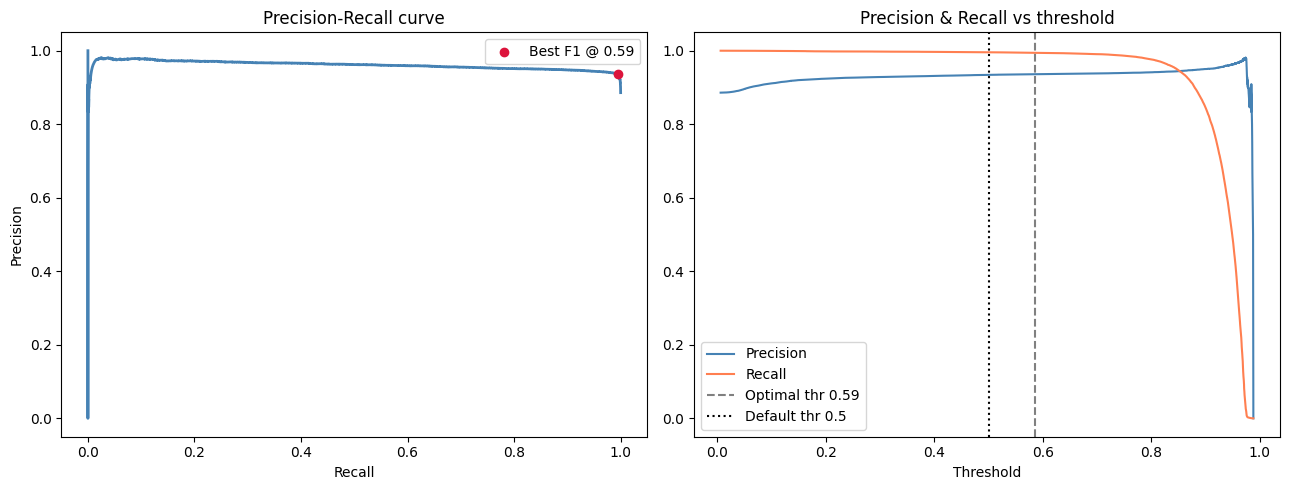

Default threshold 0.5:           F1=0.9641
Optimal threshold 0.59:  F1=0.9643


In [4]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2*(precision*recall)/(precision+recall+1e-9)
best_idx  = f1_scores.argmax()
best_thr  = thresholds[best_idx]


fig, axes = plt.subplots(1,2,figsize=(13,5))


axes[0].plot(recall, precision, color='steelblue', lw=2)
axes[0].scatter(recall[best_idx], precision[best_idx],
                color='crimson', zorder=5, label=f'Best F1 @ {best_thr:.2f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curve')
axes[0].legend()


axes[1].plot(thresholds, precision[:-1], label='Precision', color='steelblue')
axes[1].plot(thresholds, recall[:-1],    label='Recall',    color='coral')
axes[1].axvline(best_thr, color='gray', ls='--', label=f'Optimal thr {best_thr:.2f}')
axes[1].axvline(0.5,      color='black',ls=':',  label='Default thr 0.5')
axes[1].set(xlabel='Threshold', title='Precision & Recall vs threshold')
axes[1].legend()


plt.tight_layout(); plt.savefig('threshold_analysis.png',dpi=120); plt.show()


print(f'Default threshold 0.5:           F1={f1_score(y_test,y_prob>=0.5):.4f}')
print(f'Optimal threshold {best_thr:.2f}:  F1={f1_score(y_test,y_prob>=best_thr):.4f}')


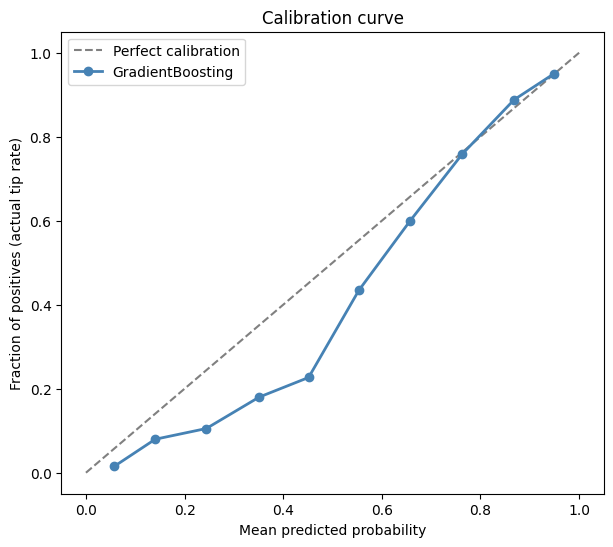

Brier score: 0.0590  (0=perfect, 0.25=random on balanced data)

If curve ABOVE diagonal → model under-confident (real rate > predicted)
If curve BELOW diagonal → model over-confident (real rate < predicted)
GradientBoosting typically curves slightly below — document this.


In [5]:
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)


fig, ax = plt.subplots(figsize=(7,6))
ax.plot([0,1],[0,1], ls='--', color='gray', label='Perfect calibration')
ax.plot(mean_pred, frac_pos, marker='o', color='steelblue', lw=2,
        label='GradientBoosting')
ax.set(xlabel='Mean predicted probability',
       ylabel='Fraction of positives (actual tip rate)',
       title='Calibration curve')
ax.legend()
plt.savefig('calibration.png',dpi=120); plt.show()


brier = brier_score_loss(y_test, y_prob)
print(f'Brier score: {brier:.4f}  (0=perfect, 0.25=random on balanced data)')
print()
print('If curve ABOVE diagonal → model under-confident (real rate > predicted)')
print('If curve BELOW diagonal → model over-confident (real rate < predicted)')
print('GradientBoosting typically curves slightly below — document this.')


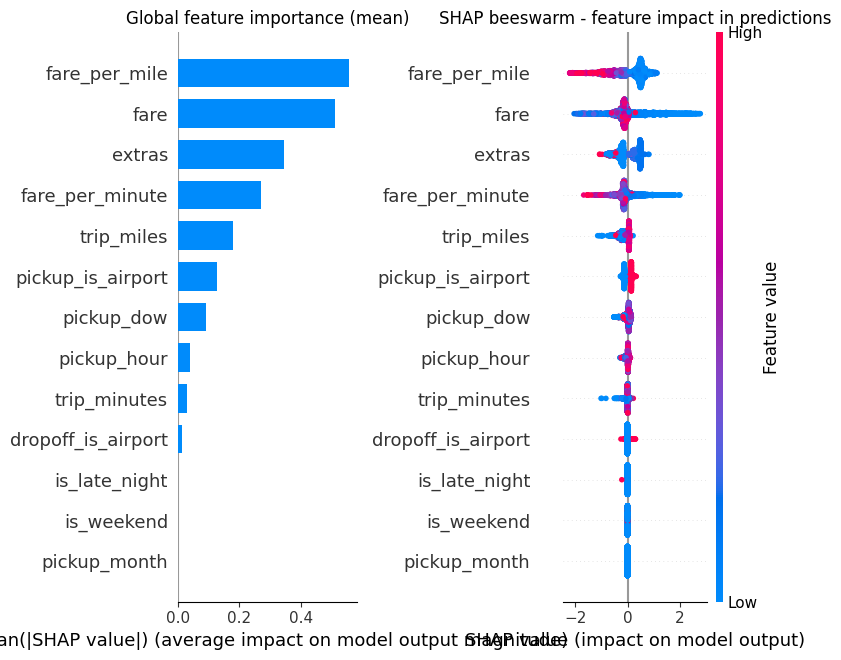

In [6]:
import shap


# TreeExplainer is optimised for GBT — fast and exact
explainer    = shap.TreeExplainer(model)
X_sample     = X_test.sample(3000, random_state=42)
shap_values  = explainer.shap_values(X_sample)


fig, axes = plt.subplots(1,2,figsize=(16,16))


# Global importance — mean |SHAP| per feature
plt.sca(axes[0])
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
axes[0].set_title('Global feature importance (mean)')


# Beeswarm — direction and magnitude per observation
plt.sca(axes[1])
shap.summary_plot(shap_values, X_sample, show=False)
axes[1].set_title('SHAP beeswarm - feature impact in predictions')


plt.tight_layout(); plt.savefig('shap_summary.png',dpi=120); plt.show()


In [7]:
import numpy as np
import shap

# 1. Recalculate probabilities ONLY on the 3000-row sample
# (Assuming a scikit-learn style model. If it's a deep learning model, use model.predict(X_sample))
y_prob_sample = model.predict_proba(X_sample)[:, 1] 

# 2. Find the uncertain indices within this matched 3000-row subset
uncertain_idx = np.abs(y_prob_sample - 0.5).argsort()[:10]

# trip_idx is now guaranteed to be between 0 and 2999
trip_idx      = uncertain_idx[0] 

# 3. Construct the Explanation object (using the .iloc fix from earlier)
explanation = shap.Explanation(
    values        = shap_values[trip_idx], 
    base_values   = explainer.expected_value,
    data          = X_sample.iloc[trip_idx].values, 
    feature_names = FEATURES
)

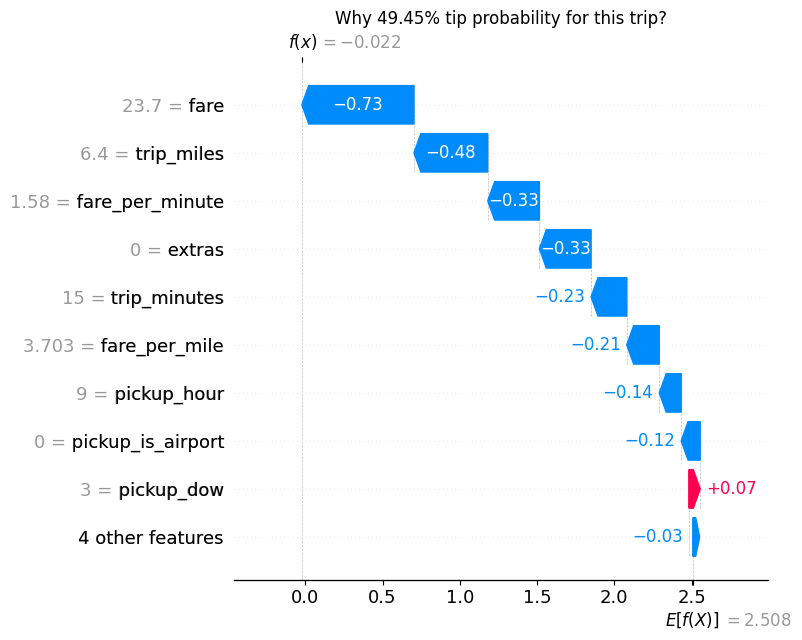

Trip features:
pickup_hour            9.000000
pickup_dow             3.000000
pickup_month           2.000000
is_weekend             0.000000
is_late_night          0.000000
trip_miles             6.400000
trip_minutes          15.000000
fare_per_mile          3.703125
fare_per_minute        1.580000
extras                 0.000000
fare                  23.700000
pickup_is_airport      0.000000
dropoff_is_airport     0.000000
Name: 18998, dtype: float64

Predicted: 49.45%  |  Actual: No tip


In [8]:
import numpy as np
import shap
import matplotlib.pyplot as plt

original_row_label = X_sample.index[trip_idx]

# --- THE FIX: Extracting the actual scalar numbers ---

# 1. Fix the Base Value
if isinstance(explainer.expected_value, (np.ndarray, list)):
    # If it's a binary classifier returning 2 values, grab the positive class [1]
    # If it's a single value array, grab the only value [0]
    base_val = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
else:
    base_val = explainer.expected_value

# 2. Fix the SHAP Values (if your model outputs multi-class/binary lists)
if isinstance(shap_values, list):
    # Grab the SHAP values for the positive class [1], then slice the row
    single_row_shap = shap_values[1][trip_idx]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # If it's a 3D array (samples, features, classes), slice row and positive class
    single_row_shap = shap_values[trip_idx, :, 1]
else:
    # Standard 2D array
    single_row_shap = shap_values[trip_idx]

# 3. Construct the Explanation safely
explanation = shap.Explanation(
    values        = single_row_shap, 
    base_values   = base_val,
    data          = X_sample.iloc[trip_idx].values, 
    feature_names = FEATURES
)

# --- VISUALS & PRINTS ---

fig = plt.figure(figsize=(10,5))
shap.plots.waterfall(explanation, show=False)

# Title uses the 1D y_prob_sample array we created in the last step
plt.title(f'Why {y_prob_sample[trip_idx]:.2%} tip probability for this trip?')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120)
plt.show()

print('Trip features:')
print(X_test.loc[original_row_label])

actual_target = y_test.loc[original_row_label]
print(f'\nPredicted: {y_prob_sample[trip_idx]:.2%}  |  Actual: {"Tipped" if actual_target == 1 else "No tip"}')

In [9]:
with mlflow.start_run(run_id="dc42c5e9bb4045ba865e7ea606441614"):
    for f in ['confusion_matrix.png','threshold_analysis.png',
              'calibration.png','shap_summary.png','shap_waterfall.png']:
        mlflow.log_artifact(f)
    mlflow.log_metric('optimal_threshold', best_thr)
    mlflow.log_metric('f1_at_optimal',     f1_score(y_test, y_prob>=best_thr))
    mlflow.log_metric('f1_at_default',     f1_score(y_test, y_prob>=0.5))
#print('Artefacts logged. View: mlflow ui --backend-store-uri file:./mlruns --port 5000')


In [10]:
from prefect import flow

@flow(log_prints=True)
def test():
    print('Prefect is connected')